# Activity: Perform logistic regression 

## Introduction

In this activity, you will complete an effective bionomial logistic regression. This exercise will help you better understand the value of using logistic regression to make predictions for a dependent variable based on one independent variable and help you build confidence in practicing logistic regression. Because logistic regression is leveraged across a wide array of industries, becoming proficient in this process will help you expand your skill set in a widely-applicable way.   

For this activity, you work as a consultant for an airline. The airline is interested in knowing if a better in-flight entertainment experience leads to higher customer satisfaction. They would like you to construct and evaluate a model that predicts whether a future customer would be satisfied with their services given previous customer feedback about their flight experience.

The data for this activity is for a sample size of 129,880 customers. It includes data points such as class, flight distance, and in-flight entertainment, among others. Your goal will be to utilize a binomial logistic regression model to help the airline model and better understand this data. 

Because this activity uses a dataset from the industry, you will need to conduct basic EDA, data cleaning, and other manipulations to prepare the data for modeling.

In this activity, you will practice the following skills:

* Importing packages and loading data
* Exploring the data and completing the cleaning process
* Building a binomial logistic regression model 
* Evaluating a binomial logistic regression model using a confusion matrix

## Step 1: Imports

### Import packages

Import relevant Python packages. Use `train_test_split`, `LogisticRegression`, and various imports from `sklearn.metrics` to build, visualize, and evalute the model.

In [64]:
### YOUR CODE HERE ###

# Standard operational package imports.
import numpy as np
import pandas as pd


# Important imports for preprocessing, modeling, and evaluation.
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import sklearn.metrics as metrics

# Visualization package imports.
import matplotlib.pyplot as plt
import seaborn as sns


### Load the dataset

The dataset **Invistico_Airline.csv** is loaded. The resulting pandas DataFrame is saved as a variable named `df_original`. As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [65]:
# RUN THIS CELL TO IMPORT YOUR DATA.

### YOUR CODE HERE ###
df_original = pd.read_csv("Invistico_Airline.csv")

<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Use a function from the pandas library to read in the csv file.
    
</details>

<details>
  <summary><h4><strong>Hint 2</strong></h4></summary>

Use the `read_csv` function and pass in the file name as a string. 

</details>

<details>
  <summary><h4><strong>Hint 3</strong></h4></summary>

Use `pd.read_csv("insertfilenamehere")`.

</details>

### Output the first 10 rows

Output the first 10 rows of data.

In [66]:
### YOUR CODE HERE ###
df_original.head(n = 10)

,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0
5,satisfied,Loyal Customer,30,Personal Travel,Eco,1894,0,0,0,3,...,2,2,5,4,5,5,4,2,0,0.0
6,satisfied,Loyal Customer,66,Personal Travel,Eco,227,0,0,0,3,...,5,5,5,0,5,5,5,3,17,15.0
7,satisfied,Loyal Customer,10,Personal Travel,Eco,1812,0,0,0,3,...,2,2,3,3,4,5,4,2,0,0.0
8,satisfied,Loyal Customer,56,Personal Travel,Business,73,0,0,0,3,...,5,4,4,0,1,5,4,4,0,0.0
9,satisfied,Loyal Customer,22,Personal Travel,Eco,1556,0,0,0,3,...,2,2,2,4,5,3,4,2,30,26.0


<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Use the `head()` function.

</details>

<details>
  <summary><h4><strong>Hint 2</strong></h4></summary>

If only five rows are output, it is because the function by default returns five rows. To change this, specify how many rows `(n = )` you want to output.

</details>

## Step 2: Data exploration, data cleaning, and model preparation

### Prepare the data

After loading the dataset, prepare the data to be suitable for a logistic regression model. This includes: 

*   Exploring the data
*   Checking for missing values
*   Encoding the data
*   Renaming a column
*   Creating the training and testing data

### Explore the data

Check the data type of each column. Note that logistic regression models expect numeric data. 

In [67]:
### YOUR CODE HERE ###
df_original.dtypes

satisfaction                          object
Customer Type                         object
Age                                    int64
Type of Travel                        object
Class                                 object
Flight Distance                        int64
Seat comfort                           int64
Departure/Arrival time convenient      int64
Food and drink                         int64
Gate location                          int64
Inflight wifi service                  int64
Inflight entertainment                 int64
Online support                         int64
Ease of Online booking                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Cleanliness                            int64
Online boarding                        int64
Departure Delay in Minutes             int64
Arrival Delay in Minutes             float64
dtype: obj

<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Use the `dtypes` attribute on the DataFrame.

</details>

### Check the number of satisfied customers in the dataset

To predict customer satisfaction, check how many customers in the dataset are satisfied before modeling.

In [68]:
### YOUR CODE HERE ###
df_original['satisfaction'].value_counts(dropna = False)

satisfied       71087
dissatisfied    58793
Name: satisfaction, dtype: int64

<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Use a function from the pandas library that returns a pandas series containing counts of unique values. 

</details>

<details>
  <summary><h4><strong>Hint 2</strong></h4></summary>

Use the `value_counts()` function. To examine how many NaN values there are, set the `dropna` parameter passed in to this function to `False`.

</details>

**Question:** How many satisfied and dissatisfied customers were there?

There were 71,087 satisfied customers, and 58,793 dissatisfied customers.

**Question:** What percentage of customers were satisfied?

71,087/129,880 = 0.547 or 54.7%

### Check for missing values

An assumption of logistic regression models is that there are no missing values. Check for missing values in the rows of the data.

In [69]:
### YOUR CODE HERE ###
df_original.isnull().sum()

satisfaction                           0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Seat comfort                           0
Departure/Arrival time convenient      0
Food and drink                         0
Gate location                          0
Inflight wifi service                  0
Inflight entertainment                 0
Online support                         0
Ease of Online booking                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Cleanliness                            0
Online boarding                        0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
dtype: int64

<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

To get the number of rows in the data with missing values, use the `isnull` function followed by the `sum` function.

</details>

**Question:** Should you remove rows where the `Arrival Delay in Minutes` column has missing values, even though the airline is more interested in the `inflight entertainment` column?

To ensure the analysis remains accurate and retains as much useful information as possible, I chose to keep the rows with missing values and handle them appropriately rather than remove them for the these reasons:
- Preserves data size: Keeping the rows avoids unnecessarily reducing the dataset, which helps maintain statistical power.
- Retains useful information: Even though “Arrival Delay in Minutes” is missing, all other columns—especially inflight entertainment—are complete and still valuable.
- Aligns with project focus: The missing values are not in the main variable of interest, so removing rows would discard relevant insights for no strong reason.
- Reduces risk of bias: Dropping rows could skew the dataset if the missing values are not completely random.
- Supports better modeling: More data generally leads to more reliable and stable model performance.
-Allows simple handling: Missing values can be easily addressed through imputation (e.g., using the median) without losing observations.



### Drop the rows with missing values

Drop the rows with missing values and save the resulting pandas DataFrame in a variable named `df_subset`.

In [70]:
### YOUR CODE HERE ###
df_subset = df_original.dropna(axis=0).reset_index(drop = True)

<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Use the `dropna` function.

</details>

<details>
  <summary><h4><strong>Hint 2</strong></h4></summary>

Set the axis parameter passed into the `dropna` function to `0` if you want to drop rows containing missing values, or `1` if you want to drop columns containing missing values. Optionally, use reset_index to avoid a SettingWithCopy warning later in the notebook. 

</details>

### Prepare the data

If you want to create a plot (`sns.regplot`) of your model to visualize results later in the notebook, the independent variable `Inflight entertainment` cannot be "of type int" and the dependent variable `satisfaction` cannot be "of type object." 

Make the `Inflight entertainment` column "of type float." 

In [71]:
### YOUR CODE HERE ###
df_subset = df_subset.astype({"Inflight entertainment": float})

<details>
    
  <summary><h4><strong>Hint 1</strong></h4></summary>
Use the `.astype()` function with the dictionary `{"Inflight entertainment": float}` as an input.

</details>

### Convert the categorical column `satisfaction` into numeric

Convert the categorical column `satisfaction` into numeric through one-hot encoding.

In [72]:
### YOUR CODE HERE ###
df_subset = pd.get_dummies(df_subset, columns=['satisfaction'], drop_first=True)


<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Use `OneHotEncoder()` from `sklearn.preprocessing`.
</details>

<details>
  <summary><h4><strong>Hint 2</strong></h4></summary>

Call `OneHotEncoder()`, specifying the `drop` argument as `'first'` in order to remove redundant columns from the output. 

Call `.fit_transform()`, passing in the subset of the data that you want to encode (the subset consisting of `satisfaction`). 

Call `.toarray()` in order to convert the sparse matrix that `.fit_transform()` returns into an array.

</details>

<details>
  <summary><h4><strong>Hint 3</strong></h4></summary>

Index `df_subset` with a double pair of square brackets to get a DataFrame that consists of just `satisfaction`.

After getting the encoded values, update the `satisfaction` column (you can use reassignment).

</details>

### Output the first 10 rows of `df_subset`

To examine what one-hot encoding did to the DataFrame, output the first 10 rows of `df_subset`.



In [73]:
### YOUR CODE HERE ###
df_subset.head(10)

,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,...,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction_satisfied
0,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,2,...,3,3,0,3,5,3,2,0,0.0,1
1,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,0,...,3,4,4,4,2,3,2,310,305.0,1
2,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,2,...,2,3,3,4,4,4,2,0,0.0,1
3,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,3,...,1,1,0,1,4,1,3,0,0.0,1
4,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,4,...,2,2,0,2,4,2,5,0,0.0,1
5,Loyal Customer,30,Personal Travel,Eco,1894,0,0,0,3,2,...,2,5,4,5,5,4,2,0,0.0,1
6,Loyal Customer,66,Personal Travel,Eco,227,0,0,0,3,2,...,5,5,0,5,5,5,3,17,15.0,1
7,Loyal Customer,10,Personal Travel,Eco,1812,0,0,0,3,2,...,2,3,3,4,5,4,2,0,0.0,1
8,Loyal Customer,56,Personal Travel,Business,73,0,0,0,3,5,...,4,4,0,1,5,4,4,0,0.0,1
9,Loyal Customer,22,Personal Travel,Eco,1556,0,0,0,3,2,...,2,2,4,5,3,4,2,30,26.0,1


<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Use the `head()` function.

</details>

<details>
  <summary><h4><strong>Hint 2</strong></h4></summary>

If only five rows are outputted, it is because the function by default returns five rows. To change this, specify how many rows `(n = )` you want.

</details>

### Create the training and testing data

Put 70% of the data into a training set and the remaining 30% into a testing set. Create an X and y DataFrame with only the necessary variables.


In [78]:
### YOUR CODE HERE ###
x = df_subset[["Inflight entertainment"]]
y = df_subset['satisfaction_satisfied']
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=38)

<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Use `train_test_split`.

</details>

<details>
  <summary><h4><strong>Hint 2</strong></h4></summary>

If you named your independent variable `X` and your dependent variable `y`, then it would be `train_test_split(X, y, test_size=0.30, random_state=42)`.

</details>

<details>
  <summary><h4><strong>Hint 3</strong></h4></summary>

When you use `train_test_split`, pass in `42` to `random_state`. `random_state` is used so that if other data professionals run this code, they can get the same exact train test split. If you use a different random state, your results will differ. </details>

**Question:** If you want to consider customer satisfaction with your model, should you train your model to use `inflight entertainment` as your sole independent variable? 

No, it would not be appropriate to use inflight entertainment as the only independent variable when predicting customer satisfaction. Customer satisfaction is influenced by multiple factors, such as seat comfort, service quality, cleanliness, and delays, so relying on just one variable would oversimplify the problem and likely reduce the accuracy of the model. While inflight entertainment may be an important factor, it should be included alongside other relevant features to better capture the overall customer experience and produce more reliable results.

## Step 3: Model building

### Fit a LogisticRegression model to the data

Build a logistic regression model and fit the model to the training data. 

In [80]:
### YOUR CODE HERE ###
clf = LogisticRegression().fit(x_train,y_train)

<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Use `LogisticRegression()` and the `fit()` function on the training set. `LogisticRegression().fit(X_train,y_train)`.

</details>

### Obtain parameter estimates
Make sure you output the two parameters from your model. 

In [81]:
### YOUR CODE HERE ###
clf.coef_

array([[0.99117103]])

In [82]:
### YOUR CODE HERE ###
clf.intercept_

array([-3.16954481])

<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Refer to the content on [obtaining the parameter estimates](https://www.coursera.org/learn/regression-analysis-simplify-complex-data-relationships/lecture/XCLzq/construct-a-logistic-regression-model-with-python) from a logistic regression model.

</details>

<details>
  <summary><h4><strong>Hint 2</strong></h4></summary>

Call attributes to obtain the coefficient and intercept estimates.

</details>

<details>
  <summary><h4><strong>Hint 3</strong></h4></summary>

Use `.coef_` and `.intercept_`

</details>

### Create a plot of your model

Create a plot of your model to visualize results using the seaborn package.

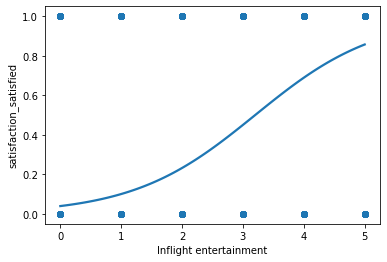

In [83]:
### YOUR CODE HERE ###
sns.regplot(x="Inflight entertainment", y="satisfaction_satisfied", data=df_subset, logistic=True, ci=None)

<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Use a function from the seaborn library that can plot data and a logistic regression model fit.
    
</details>

<details>
  <summary><h4><strong>Hint 2</strong></h4></summary>

Use the `regplot` function.

</details>

<details>
  <summary><h4><strong>Hint 3</strong></h4></summary>

Set the `logistic` parameter passed in to this function to `True` to estimate a logistic regression model.

</details>

**Question:** What can you tell from the graph?

The graph shows a clear positive relationship between inflight entertainment and customer satisfaction. As entertainment ratings increase, the probability of being satisfied also increases, following an S-shaped logistic curve. However, the spread of points indicates that not all customers with low ratings are dissatisfied and not all with high ratings are satisfied, suggesting that while inflight entertainment is an important factor, it is not the only one influencing satisfaction.

## Step 4. Results and evaluation


### Predict the outcome for the test dataset

Now that you've completed your regression, review and analyze your results. First, input the holdout dataset into the `predict` function to get the predicted labels from the model. Save these predictions as a variable called `y_pred`.

In [84]:
### YOUR CODE HERE ###

# Save predictions.
Y_pred =clf.predict (x_test)

### Print out `y_pred`

In order to examine the predictions, print out `y_pred`. 

In [86]:
### YOUR CODE HERE ###
y_pred = clf.predict(x_test)
print(y_pred)

[0 1 1 ... 0 0 0]


### Use the `predict_proba` and `predict` functions on `X_test`

In [87]:
# Use predict_proba to output a probability.

### YOUR CODE HERE ###
clf.predict_proba(x_test)

array([[0.95967197, 0.04032803],
       [0.31106623, 0.68893377],
       [0.31106623, 0.68893377],
       ...,
       [0.95967197, 0.04032803],
       [0.89829059, 0.10170941],
       [0.76624041, 0.23375959]])

<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Using the `predict_proba` function on `X_test` will produce the probability that each observation is a 0 or 1. 

</details>

In [88]:
# Use predict to output 0's and 1's.

### YOUR CODE HERE ###
clf.predict(x_test)

array([0, 1, 1, ..., 0, 0, 0], dtype=uint8)

<details>
  <summary><h4><strong>Hint 2</strong></h4></summary>

`clf.predict` outputs an array of 0's and 1's, where 0's are unsatisfied and 1's are satisfied. 

</details>

### Analyze the results

Print out the model's accuracy, precision, recall, and F1 score.

In [89]:
### YOUR CODE HERE ###
print("Accuracy:", "%.6f" % metrics.accuracy_score(y_test, y_pred))
print("Precision:", "%.6f" % metrics.precision_score(y_test, y_pred))
print("Recall:", "%.6f" % metrics.recall_score(y_test, y_pred))
print("F1 Score:", "%.6f" % metrics.f1_score(y_test, y_pred))

Accuracy: 0.802250
Precision: 0.816164
Recall: 0.822028
F1 Score: 0.819085


<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Use four different functions from `metrics` to get the accuracy, precision, recall, and F1 score.
    
</details>  

<details>
  <summary><h4><strong>Hint 2</strong></h4></summary>

Input `y_test` and `y_pred` into the `metrics.accuracy_score`, `metrics.precision_score`, `metrics.recall_score`, and `metrics.f1_score` functions. 
    
</details> 

### Produce a confusion matrix

Data professionals often like to know the types of errors made by an algorithm. To obtain this information, produce a confusion matrix.

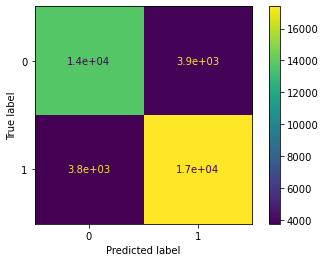

In [90]:
### YOUR CODE HERE ###
cm = metrics.confusion_matrix(y_test, y_pred, labels = clf.classes_)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix = cm,display_labels = clf.classes_)
disp.plot()

**Question:** What stands out to you about the confusion matrix?

Two of the quadrants have counts below 4,000, which are relatively low and correspond to the false positives and false negatives. In contrast, the other two quadrants—true positives and true negatives—have much higher counts, both exceeding 13,000, indicating that the model is making a large number of correct predictions.

<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Refer to [the content about plotting a confusion matrix](https://www.coursera.org/learn/regression-analysis-simplify-complex-data-relationships/lecture/SpRqe/evaluate-a-binomial-logistic-regression-model).

</details>

**Question:** Did you notice any difference in the number of false positives or false negatives that the model produced?

There is very little difference between the number of false positives and false negatives. Both are around 3,800–3,900, which indicates the model is fairly balanced in its errors and does not strongly favor one type of misclassification over the other.

**Question:** What do you think could be done to improve model performance?

Model performance could likely be improved by incorporating more relevant features instead of relying on just inflight entertainment. Customer satisfaction is influenced by multiple factors—such as seat comfort, service quality, cleanliness, and delays—so including these variables would help the model capture more meaningful patterns. Tuning the model’s parameters, trying different algorithms, or using techniques like cross-validation could further enhance accuracy. Using a more comprehensive set of inputs and refining the model setup would lead to better performance.

## Considerations

**What are some key takeaways that you learned from this lab?**

I learned how regression models work, specifically logistic regression, which are used to make predictions. I learned that logistic regression helps estimate the probability of an outcome, such as whether a customer is satisfied or not, based on input features. I also saw how the model is trained using .fit() and then used to make predictions with .predict(). Additionally, I learned how to evaluate the model’s performance using tools like the confusion matrix. Overall, this lab showed me how regression models can be used to understand relationships in data and make informed predictions.

**What findings would you share with others?**

The logistic regression model predicted customer satisfaction correctly about 80% of the time. The confusion matrix also shows a good balance, with similar numbers of true positives and true negatives, indicating the model performs consistently across both classes.

**What would you recommend to stakeholders?**

Customers who gave higher ratings for inflight entertainment were generally more likely to be satisfied, showing a clear positive relationship. This suggests that improving inflight entertainment could help increase overall customer satisfaction. The model achieved about 80% accuracy, which is a noticeable improvement compared to the baseline satisfaction rate of around 55%. This indicates the model is useful, but it could likely be improved further by including more features. Expanding the model to incorporate additional variables would not only improve prediction accuracy but also provide deeper insights into what factors most influence customer satisfaction.


**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged. 